*<small>Last updated: 2026-06-05 21:05:13 UTC | Student Version (No Solutions)</small>*

# Linear Regression: Pipelines, Regularization, and Online Learning

**Course**: Machine Learning Labs  
**Lab**: 01 — Linear Regression  

---

## Table of Contents

1. [Setup and Imports](#setup)
2. [Introduction](#intro)
3. [Part 1 — Sklearn Pipelines with Ridge Regression](#part1)
   - 3.1 [Dataset: California Housing](#data1)
   - 3.2 [Why Pipelines?](#pipelines)
   - 3.3 [Building the Ridge Pipeline](#build)
   - 3.4 [Hyperparameter Tuning with GridSearchCV](#gridsearch)
   - 3.5 [Model Evaluation](#eval1)
   - [Exercise 1.1 — Effect of Polynomial Degree](#ex11)
   - [Exercise 1.2 — Ridge vs. Lasso](#ex12)
4. [Part 2 — Online Learning with SGDRegressor](#part2)
   - 4.1 [When Data Doesn't Fit in Memory](#scale)
   - 4.2 [Dataset: Year Prediction MSD](#data2)
   - 4.3 [SGDRegressor and `partial_fit`](#sgd)
   - [Exercise 2.1 — Implement the Mini-Batch Training Loop](#ex21)
   - [Exercise 2.2 — Plot the Convergence Curve](#ex22)
   - [Exercise 2.3 — Multi-Epoch Training](#ex23)
   - [Exercise 2.4 — Learning Rate Exploration](#ex24)
   - [Exercise 2.5 — Learning Rate Schedules](#ex25)
5. [Real-World Considerations](#realworld)
6. [Summary and Key Takeaways](#summary)

---

**Estimated Time**: 3–4 hours  
**Prerequisites**: Python, NumPy, Pandas, introductory supervised learning



## 📔 Resolution

   After the deadline, you will find the resolution at the following Notion link:

https://app.notion.com/p/R-Reg-lineal-python-intro-2780573743578010af37de77f8e24bee?source=copy_link

   Remember that there are several ways to solve the proposed activities in the labs.
   Use the provided resolution as a reference. If the resolution link is not public,
   request access at the same Notion link.

## 🚚 Deliverables

**Don't forget to duplicate this notebook to be able to edit: File -> Save a copy in Drive**

In this lab, you do not need to write a report in a separate document. Please complete all required
activities within this Google Colab notebook. Remember that a notebook allows you to enter text
elements similarly to a document processor. Once the proposed activities are completed, you must
submit the following on the platform:

1. A PDF file generated in Google Colab from the menu "File" -> "Print".

2. The public Google Colab link. To do so, go to the share button and change the sharing settings
   to "Anyone with the link".


---
<a id='setup'></a>
## 1. Setup and Imports


In [2]:
# Install / upgrade packages when running in Google Colab
try:
    import google.colab
    IN_COLAB = True
    import subprocess
    subprocess.run(['pip', 'install', '--quiet', '--upgrade',
                    'scikit-learn>=1.3', 'seaborn>=0.12'], check=True)
    print('Colab environment ready.')
except ImportError:
    IN_COLAB = False
    print('Local environment detected.')


Local environment detected.


In [3]:
import os
import warnings
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, FunctionTransformer
from sklearn.linear_model import Ridge, Lasso, SGDRegressor
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error

import sklearn
print(f'scikit-learn : {sklearn.__version__}')
print(f'NumPy        : {np.__version__}')
print(f'Pandas       : {pd.__version__}')

warnings.filterwarnings('ignore')

scikit-learn : 1.8.0
NumPy        : 2.4.4
Pandas       : 2.3.3


In [4]:
# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Part 1: Pipeline / GridSearch ────────────────────────────────────────────
TEST_SIZE  = 0.2
CV_FOLDS   = 5
POLY_DEGREE = 3          # Exercise 1.1: try 1 or 3
ALPHAS     = np.logspace(-4, 4, 30)

# ── Part 2: Online Learning ───────────────────────────────────────────────────
CHUNK_SIZE     = 5_000
N_EPOCHS       = 10
MSD_TRAIN_ROWS = 463_715   # official UCI split: first 463,715 rows are training
MSD_TEST_ROWS  = 51_630    # last 51,630 rows are test (total = 515,345)
MSD_DATA_FILE  = 'YearPredictionMSD.txt'
MSD_URL        = ('https://archive.ics.uci.edu/ml/machine-learning-databases'
                  '/00203/YearPredictionMSD.txt.zip')

# ── Plotting defaults ─────────────────────────────────────────────────────────
os.makedirs('assets', exist_ok=True)
plt.rcParams.update({
    'figure.figsize'   : (11, 5),
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11,
})
COLORS = ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']

print('Configuration ready.')

Configuration ready.


---
<a id='intro'></a>
## 2. Introduction

Linear regression is the foundation of supervised machine learning. Despite its simplicity, it remains one of the most widely deployed models in industry — from predicting house prices to forecasting energy demand. Mastering it means mastering the core ideas that every more complex model builds on: loss functions, gradient descent, regularization, and generalization.

This lab covers two perspectives on linear regression:

**Part 1 — Sklearn Pipelines with Ridge Regression** (instructor walkthrough)  
You will build a complete machine-learning pipeline that chains polynomial feature expansion, feature scaling, and Ridge regression. You will use `GridSearchCV` to tune the regularization strength λ (alpha) and visualize the classic bias–variance tradeoff through a train/validation error curve.

**Part 2 — Online Learning with SGDRegressor** (student activity)  
You will train a linear model on a dataset that is too large to hold in memory at once — the **Year Prediction MSD** dataset, a subset of the Million Song Dataset with 515 K songs and 90 audio features. You will use `SGDRegressor.partial_fit` to process the data in mini-batches, monitor convergence, and experimentally discover how the learning rate drives convergence or catastrophic divergence.

### Learning Objectives

By the end of this lab you will be able to:

1. Explain why preprocessing steps must be wrapped in a `Pipeline` to prevent data leakage during cross-validation.
2. Build a multi-step sklearn `Pipeline` combining feature engineering, scaling, and a regularized estimator.
3. Use `GridSearchCV` to perform principled hyperparameter search and interpret the resulting validation curve.
4. Describe the difference between batch, stochastic, and mini-batch gradient descent.
5. Implement online / incremental learning with `SGDRegressor.partial_fit` on chunked data.
6. Diagnose learning-rate divergence and understand the role of learning-rate schedules.


---
<a id='part1'></a>
## 3. Part 1 — Sklearn Pipelines with Ridge Regression

<a id='data1'></a>
### 3.1 Dataset: California Housing

We use the **California Housing** dataset, derived from the 1990 US Census. Each row represents one census block group; the task is to predict the **median house value** (in units of \$100,000).

| Feature | Description |
|---------|-------------|
| `MedInc` | Median household income in block |
| `HouseAge` | Median house age in block |
| `AveRooms` | Average number of rooms |
| `AveBedrms` | Average number of bedrooms |
| `Population` | Block population |
| `AveOccup` | Average occupancy per household |
| `Latitude` | Block latitude |
| `Longitude` | Block longitude |

**Target**: `MedHouseVal` — median house value in \$100 K (range 0.15 – 5.0).


In [5]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
X  = df.drop('MedHouseVal', axis=1)
y  = df['MedHouseVal']

print(f'Samples  : {df.shape[0]:,}')
print(f'Features : {X.shape[1]}')
print(f'Target   : MedHouseVal  min={y.min():.2f}  max={y.max():.2f}  mean={y.mean():.2f}')
print()
display(df.describe().round(2))


Samples  : 20,640
Features : 8
Target   : MedHouseVal  min=0.15  max=5.00  mean=2.07



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


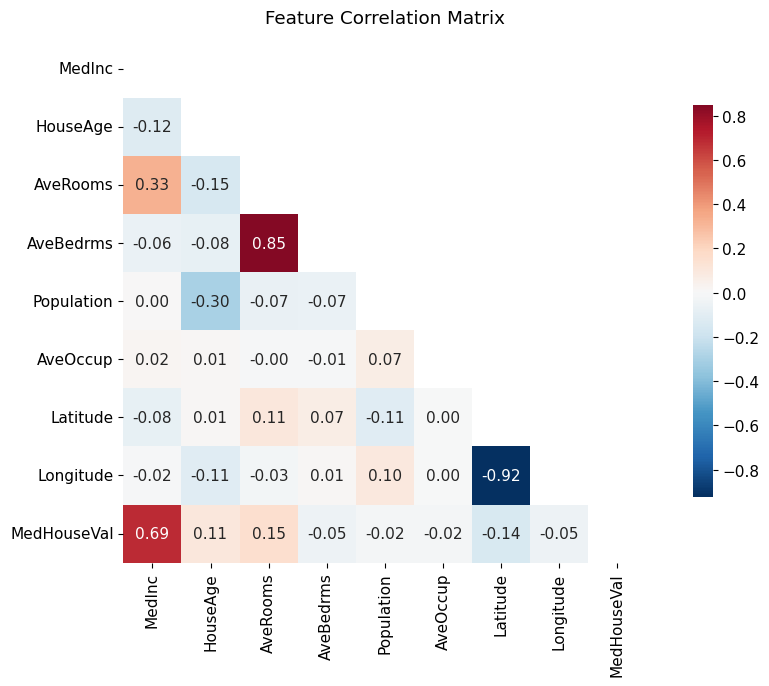

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(
    df.corr(), mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, square=True, ax=ax,
    cbar_kws={'shrink': 0.75}
)
ax.set_title('Feature Correlation Matrix', pad=12)
plt.tight_layout()
plt.savefig('assets/california_correlation.png', dpi=120, bbox_inches='tight')
plt.show()


**Conclusion from the correlation matrix**: `MedInc` (median income) has the highest correlation with the target (`MedHouseVal`) at **≈ 0.69**, well above the next strongest predictor `AveRooms` (≈ 0.15 after accounting for sign). The scatter plot below focuses on this dominant feature and reveals a non-linear curve — motivating polynomial feature expansion in Section 3.3.

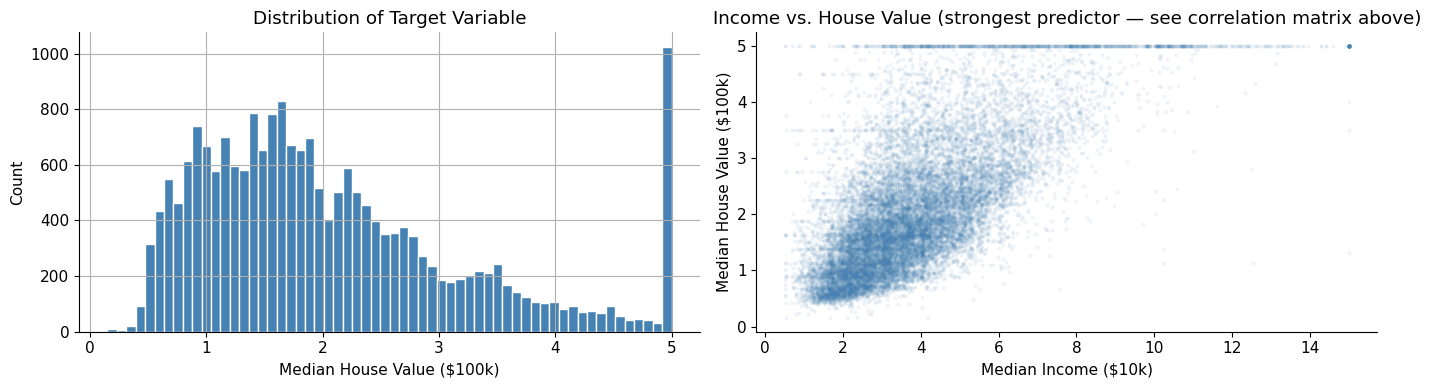

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

y.hist(bins=60, ax=axes[0], color=COLORS[0], edgecolor='white')
axes[0].set_xlabel('Median House Value ($100k)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Target Variable')

axes[1].scatter(df['MedInc'], y, alpha=0.06, s=4, color=COLORS[0])
axes[1].set_xlabel('Median Income ($10k)')
axes[1].set_ylabel('Median House Value ($100k)')
axes[1].set_title('Income vs. House Value (strongest predictor — see correlation matrix above)')

plt.tight_layout()
plt.savefig('assets/california_eda.png', dpi=120, bbox_inches='tight')
plt.show()



### The $500k Ceiling: Censored Data

The histogram above shows a visible spike at $500k (5.0 in $100k units). This is **not** a market phenomenon — it is a **data collection artifact**. In the 1990 census, median house values above $500k were all recorded as exactly $500k. Statistically, these are **right-censored observations**: we know the true value is ≥ $500k, but not by how much.

Training a regression model on censored targets creates systematic bias: the model is penalized for every block whose true value exceeds $500k, yet it has no signal to learn the correct magnitude. The result is a distorted loss landscape near the ceiling.

**Decision**: We filter out the ~965 censored rows (≈ 4.7% of data) and restrict the model to the $15k–$500k range. This is a **data-scope decision**, not data cleaning — the removed rows are not wrong, just incomplete.

In [8]:
n_total  = len(df)
n_capped = (df['MedHouseVal'] >= 5.0).sum()
print(f"Censored rows (MedHouseVal == $500k): {n_capped} / {n_total} ({n_capped / n_total:.1%})")

df = df[df['MedHouseVal'] < 5.0].copy()
X  = df.drop('MedHouseVal', axis=1)
y  = df['MedHouseVal']

print(f"Dataset after filtering: {len(df):,} rows")
print(f"Target range now: ${y.min() * 100_000:,.0f} – ${y.max() * 100_000:,.0f}")

Censored rows (MedHouseVal == $500k): 992 / 20640 (4.8%)
Dataset after filtering: 19,648 rows
Target range now: $14,999 – $499,100


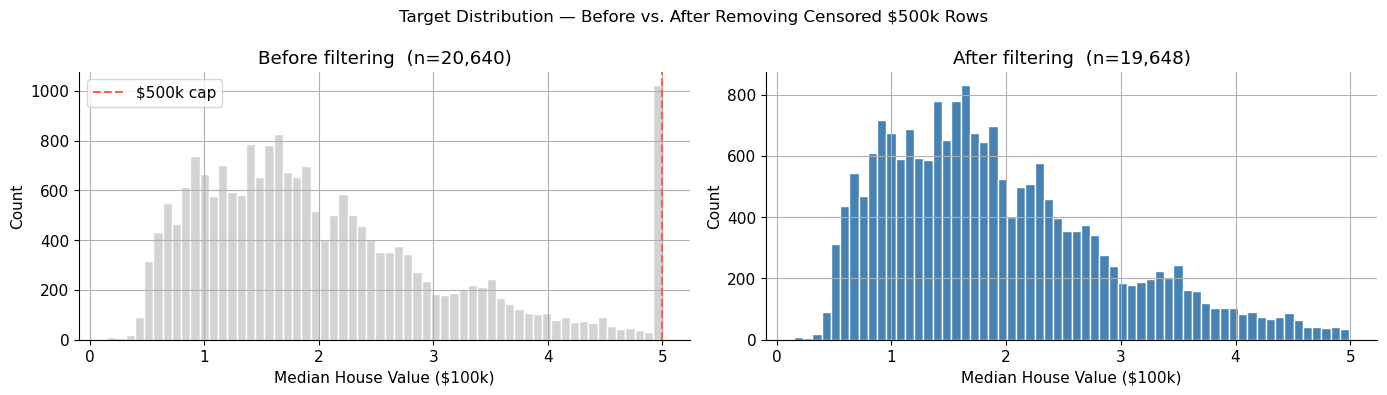

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

housing.frame['MedHouseVal'].hist(bins=60, ax=axes[0], color='lightgray', edgecolor='white')
axes[0].axvline(5.0, color=COLORS[1], linestyle='--', lw=1.5, label='$500k cap')
axes[0].set_xlabel('Median House Value ($100k)')
axes[0].set_ylabel('Count')
axes[0].set_title('Before filtering  (n=20,640)')
axes[0].legend()

y.hist(bins=60, ax=axes[1], color=COLORS[0], edgecolor='white')
axes[1].set_xlabel('Median House Value ($100k)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'After filtering  (n={len(df):,})')

plt.suptitle('Target Distribution — Before vs. After Removing Censored $500k Rows', fontsize=12)
plt.tight_layout()
plt.savefig('assets/target_distribution_filtered.png', dpi=120, bbox_inches='tight')
plt.show()

<a id='skewness'></a>
### 3.1.1 Feature Skewness and Log Transforms

Raw features are rarely on a nice, symmetric scale — and that matters for linear models:

1. **Outliers dominate OLS.** Squared-error loss amplifies extreme values. `AveOccup` has a maximum of 1243 vs. a median of ~2.8 — a single such block can pull the fit away from the rest of the data.
2. **Log-linear relationships.** If house value grows *proportionally* with income (rather than additively), the true relationship is linear in *log(income)*. A model fit on raw income will struggle to capture this curve.

`log1p(x) = log(1 + x)` compresses right tails and safely handles zero values.

**Rule of thumb**: |skewness| > 1 → consider a log transform.

Feature skewness (sorted):
AveOccup      95.41
AveBedrms     29.74
AveRooms      16.61
Population     4.96
MedInc         0.91
Latitude       0.46
HouseAge       0.07
Longitude     -0.29

Features to log-transform (|skew| > 1): ['MedInc', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
Features to passthrough                : ['HouseAge', 'Latitude', 'Longitude']


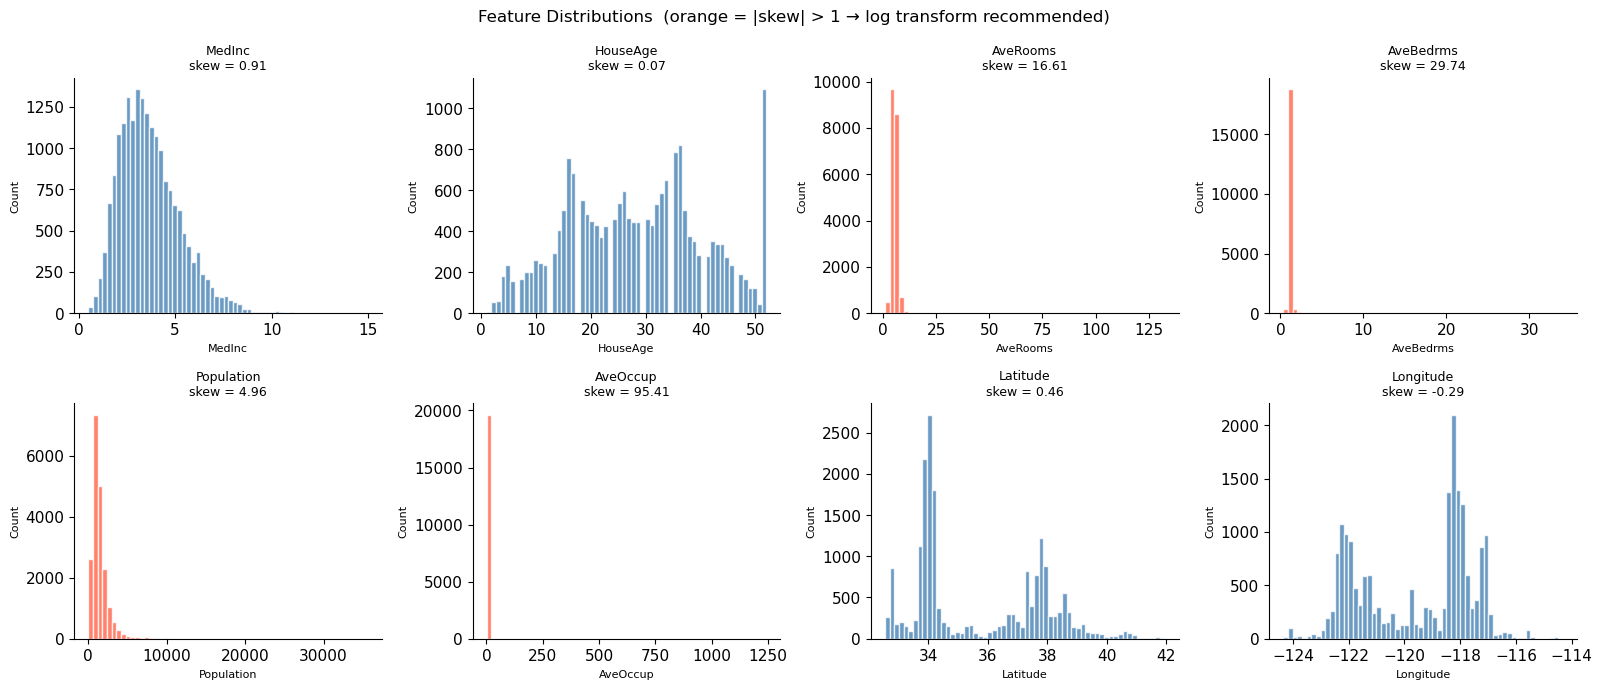

In [10]:
LOG_FEATURES  = ['MedInc', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
PASS_FEATURES = [c for c in X.columns if c not in LOG_FEATURES]

# Compute skewness for all features
feature_skewness = X.skew().sort_values(ascending=False)
print('Feature skewness (sorted):')
print(feature_skewness.round(2).to_string())
print()
print('Features to log-transform (|skew| > 1):', LOG_FEATURES)
print('Features to passthrough                :', PASS_FEATURES)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    skew_val = X[col].skew()
    color = COLORS[1] if abs(skew_val) > 1 else COLORS[0]
    axes[i].hist(X[col], bins=60, color=color, edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col}\nskew = {skew_val:.2f}', fontsize=9)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel('Count', fontsize=8)

plt.suptitle('Feature Distributions  (orange = |skew| > 1 → log transform recommended)', fontsize=12)
plt.tight_layout()
plt.savefig('assets/feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

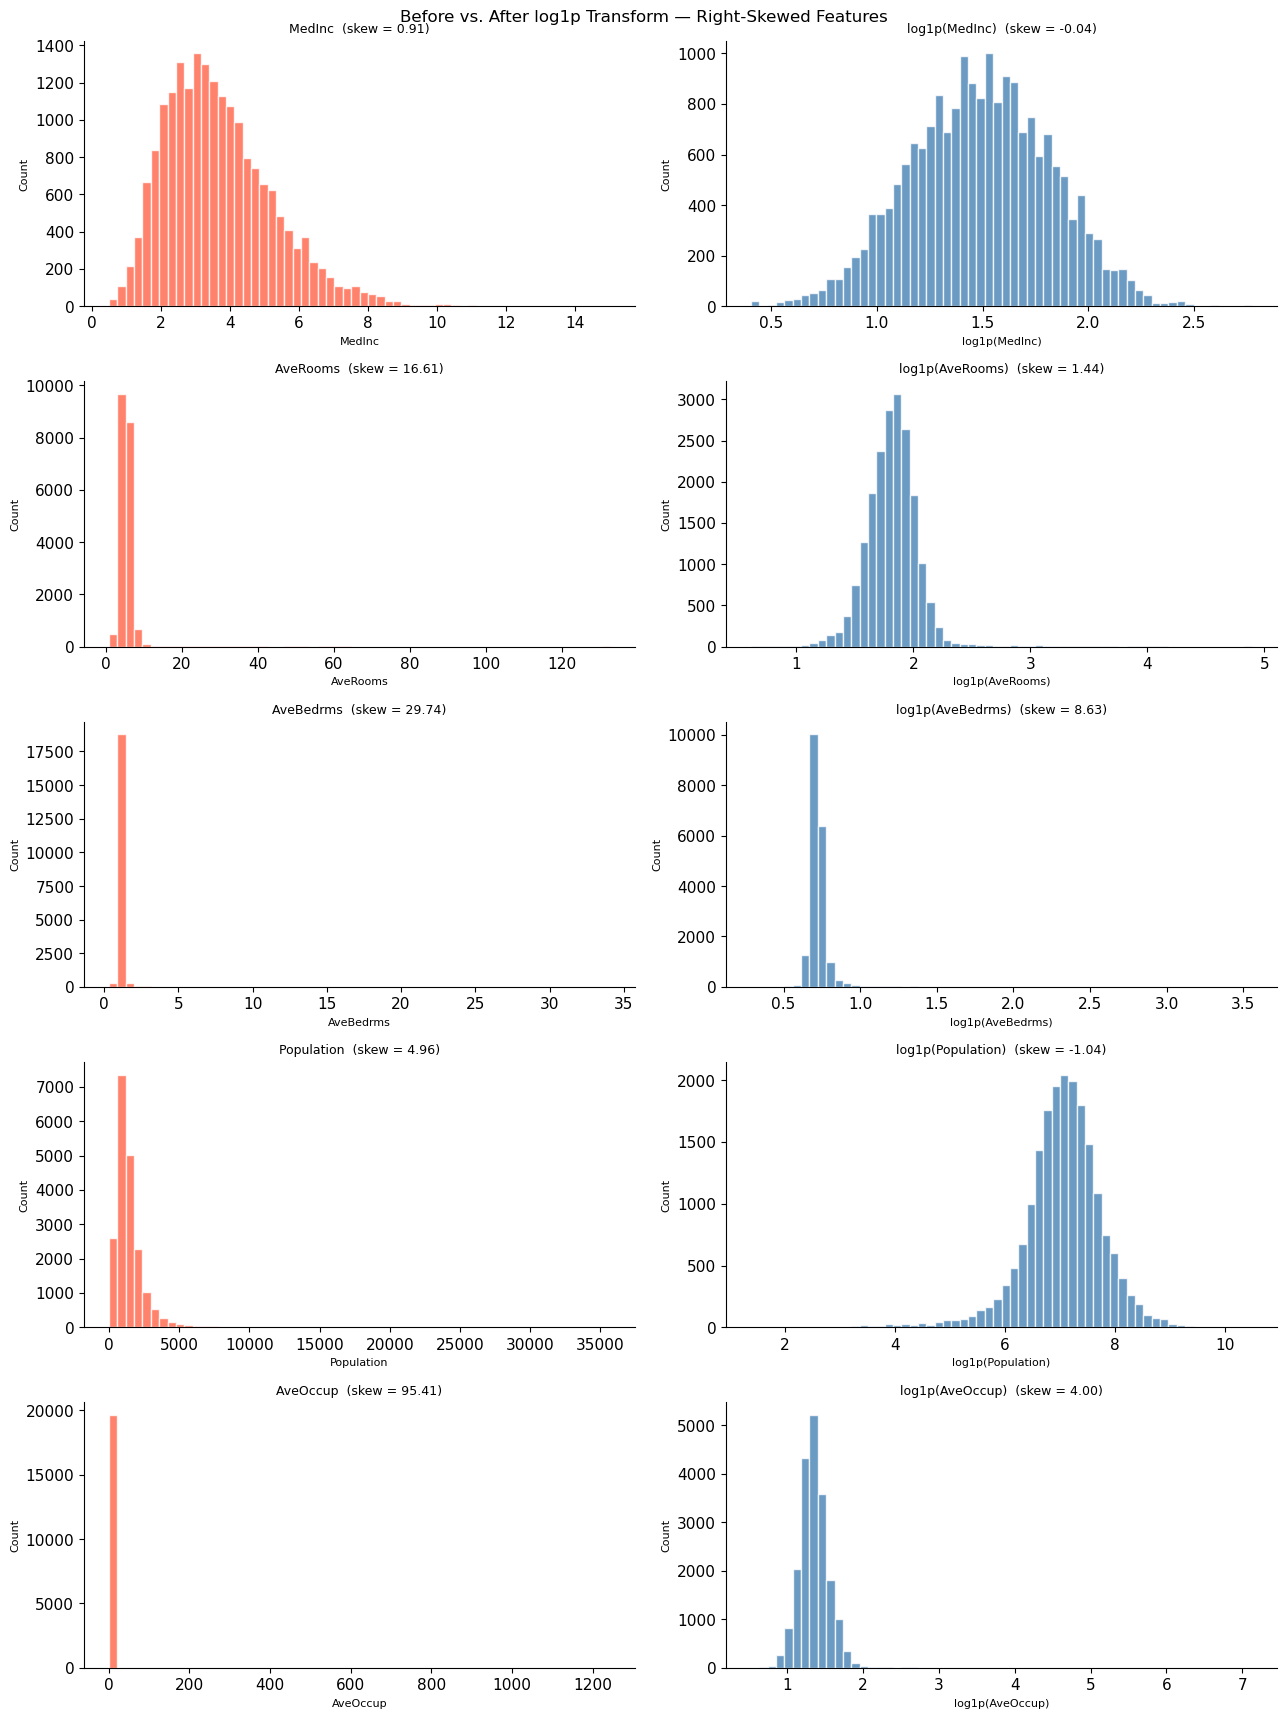

In [11]:
fig, axes = plt.subplots(len(LOG_FEATURES), 2, figsize=(13, 3.5 * len(LOG_FEATURES)))

for i, col in enumerate(LOG_FEATURES):
    axes[i, 0].hist(X[col], bins=60, color=COLORS[1], edgecolor='white', alpha=0.8)
    axes[i, 0].set_title(f'{col}  (skew = {X[col].skew():.2f})', fontsize=9)
    axes[i, 0].set_xlabel(col, fontsize=8)
    axes[i, 0].set_ylabel('Count', fontsize=8)

    log_col = np.log1p(X[col])
    axes[i, 1].hist(log_col, bins=60, color=COLORS[0], edgecolor='white', alpha=0.8)
    axes[i, 1].set_title(f'log1p({col})  (skew = {log_col.skew():.2f})', fontsize=9)
    axes[i, 1].set_xlabel(f'log1p({col})', fontsize=8)
    axes[i, 1].set_ylabel('Count', fontsize=8)

plt.suptitle('Before vs. After log1p Transform — Right-Skewed Features', fontsize=12)
plt.tight_layout()
plt.savefig('assets/log_transforms.png', dpi=120, bbox_inches='tight')
plt.show()


**Remarks**
* All five features become near-symmetric after log1p.
* The ColumnTransformer in Section 3.3 applies this automatically inside the pipeline.

<a id='pipelines'></a>
### 3.2 Why Pipelines? Preventing Data Leakage

A common mistake is to fit the scaler (or any preprocessing step) on the **entire** dataset before splitting into train and test — or before cross-validation folds are formed. This is **data leakage**: the scaler learns the mean and standard deviation of the held-out samples, giving an overly optimistic evaluation.

```
# ❌ WRONG — scaler sees test data
scaler.fit(X_all)          # BUG: uses test statistics
X_scaled = scaler.transform(X_all)
X_train, X_test = train_test_split(X_scaled, ...)

# ✅ RIGHT — Pipeline re-fits the scaler inside each CV fold
pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())])
cross_val_score(pipe, X_train, y_train, cv=5)
```

With a `Pipeline`, every call to `cross_val_score` or `GridSearchCV` will:
1. Split data into train/validation folds.
2. Call `fit_transform` on the training fold (scaler learns from train only).
3. Call `transform` on the validation fold (applies the train statistics).

This guarantees a valid estimate of generalization performance.


In [12]:
# Train / test split — done once, before any fitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape[0]:,} samples')
print(f'Test : {X_test.shape[0]:,} samples')

# Quick baseline with a minimal pipeline (no poly features)
baseline_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge()),
])
baseline_cv = -cross_val_score(
    baseline_pipe, X_train, y_train,
    cv=CV_FOLDS, scoring='neg_mean_squared_error', n_jobs=-1
)
baseline_rmse = np.sqrt(baseline_cv.mean())
print(f'\nBaseline CV RMSE (Ridge, no poly): {baseline_rmse:.4f} ($100k)')


Train: 15,718 samples
Test : 3,930 samples

Baseline CV RMSE (Ridge, no poly): 0.6353 ($100k)


<a id='build'></a>
### 3.3 Building the Ridge Pipeline

The income–value scatter (Section 3.1) shows a non-linear curve. We address this at two levels:

**Step 1 — Log transforms (ColumnTransformer).**  
As shown in Section 3.1.1, five features (`MedInc`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup`) are strongly right-skewed. We apply `log1p(x) = log(1 + x)` to each. `HouseAge`, `Latitude`, and `Longitude` pass through unchanged — they are either roughly symmetric or represent coordinates without a meaningful log scale.

**Step 2 — Polynomial interaction features.**  
We use `interaction_only=True`, which adds only **pairwise products** (e.g. `log(MedInc)×Latitude`, capturing income–location pricing effects) and drops squared terms. This gives 8 original + C(8,2) = 28 interaction terms = **36 features**.

**Step 3 — StandardScaler.** Zero-mean, unit-variance scaling is required before Ridge, which penalises coefficient magnitude and is sensitive to feature scale.

**Step 4 — Ridge regression.** L2 penalty `α·‖w‖²` stabilises the fit against the many correlated interaction features.

Our full pipeline:

```
raw features  →  ColumnTransformer   →  PolynomialFeatures  →  StandardScaler  →  Ridge
(8 features)      log1p(5 features)      (interaction_only:    (zero mean,        (L2-regularized
                  passthrough(3 feat.)    8 + 28 = 36 feat.)    unit variance)      linear model)
```

**Why Ridge?** Polynomial expansion creates many correlated features. OLS is then numerically unstable and overfits. Ridge's L2 penalty shrinks weights toward zero, reducing variance at the cost of a small bias.

In [13]:
log_preprocessor = ColumnTransformer([
    ('log',  FunctionTransformer(np.log1p, feature_names_out='one-to-one'), LOG_FEATURES),
    ('pass', 'passthrough', PASS_FEATURES),
], verbose_feature_names_out=False)

pipeline = Pipeline([
    ('log_transform', log_preprocessor),
    ('poly',   PolynomialFeatures(degree=POLY_DEGREE, include_bias=False, interaction_only=False)),
    ('scaler', StandardScaler()),
    ('ridge',  Ridge()),
])

print('Log-transform features :', LOG_FEATURES)
print('Passthrough features   :', PASS_FEATURES)

n_poly_features = (
    PolynomialFeatures(degree=POLY_DEGREE, include_bias=False, interaction_only=False)
    .fit_transform(X_train)
    .shape[1]
)
print(f'\nDegree-{POLY_DEGREE} polynomial expansion: {X_train.shape[1]} → {n_poly_features} features')

Log-transform features : ['MedInc', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
Passthrough features   : ['HouseAge', 'Latitude', 'Longitude']

Degree-3 polynomial expansion: 8 → 164 features


<a id='gridsearch'></a>
### 3.4 Hyperparameter Tuning with GridSearchCV

The regularization strength **α** (called `ridge__alpha` in the pipeline) controls the bias–variance tradeoff:

- **Small α → low regularization**: the model fits training data tightly, potentially overfitting.  
- **Large α → strong regularization**: weights are shrunk toward zero, potentially underfitting.  
- **Sweet spot**: the α that minimises validation error.

`GridSearchCV` evaluates every candidate α using k-fold cross-validation and returns the one with the best mean validation score. The double underscore syntax `'ridge__alpha'` refers to the `alpha` parameter of the `ridge` step inside the pipeline.


In [14]:
param_grid = {'ridge__alpha': ALPHAS}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=CV_FOLDS,
    scoring='neg_mean_squared_error',
    return_train_score=True,
    n_jobs=1,
    verbose=6,
)

print(f'Fitting {CV_FOLDS}-fold CV over {len(ALPHAS)} alpha values ...')
grid_search.fit(X_train, y_train)
print('Done.')
print(f'\nBest alpha : {grid_search.best_params_["ridge__alpha"]:.4f}')
print(f'Best CV RMSE: {np.sqrt(-grid_search.best_score_):.4f}  (improvement over baseline: '
      f'{baseline_rmse - np.sqrt(-grid_search.best_score_):.4f})')


Fitting 5-fold CV over 30 alpha values ...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 1/5] END ridge__alpha=0.0001;, score=(train=-0.264, test=-0.361) total time=   0.4s
[CV 2/5] END ridge__alpha=0.0001;, score=(train=-0.258, test=-0.325) total time=   0.7s
[CV 3/5] END ridge__alpha=0.0001;, score=(train=-0.264, test=-0.313) total time=   0.4s
[CV 4/5] END ridge__alpha=0.0001;, score=(train=-0.270, test=-0.285) total time=   0.2s
[CV 5/5] END ridge__alpha=0.0001;, score=(train=-0.264, test=-0.372) total time=   0.6s
[CV 1/5] END ridge__alpha=0.00018873918221350977;, score=(train=-0.264, test=-0.345) total time=   0.3s
[CV 2/5] END ridge__alpha=0.00018873918221350977;, score=(train=-0.259, test=-0.324) total time=   0.6s
[CV 3/5] END ridge__alpha=0.00018873918221350977;, score=(train=-0.265, test=-0.312) total time=   0.5s
[CV 4/5] END ridge__alpha=0.00018873918221350977;, score=(train=-0.270, test=-0.281) total time=   0.4s
[CV 5/5] END ridge__alpha=0.00018873918

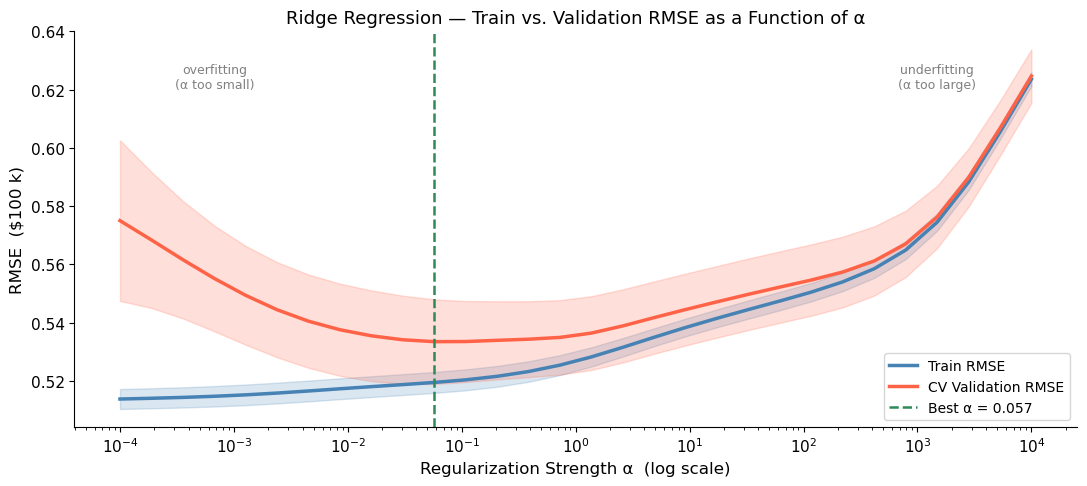

In [15]:
# ── Extract per-fold RMSE for accurate error bands ───────────────────────────
results       = pd.DataFrame(grid_search.cv_results_)
alphas_tested = results['param_ridge__alpha'].astype(float).values

fold_train_rmse = np.array([
    np.sqrt(-results[f'split{k}_train_score'].values)
    for k in range(CV_FOLDS)
])  # shape (CV_FOLDS, n_alphas)

fold_val_rmse = np.array([
    np.sqrt(-results[f'split{k}_test_score'].values)
    for k in range(CV_FOLDS)
])

train_rmse     = fold_train_rmse.mean(axis=0)
train_rmse_std = fold_train_rmse.std(axis=0)
cv_rmse        = fold_val_rmse.mean(axis=0)
cv_rmse_std    = fold_val_rmse.std(axis=0)

best_alpha = grid_search.best_params_['ridge__alpha']

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

ax.semilogx(alphas_tested, train_rmse, color=COLORS[0], lw=2.5, label='Train RMSE')
ax.fill_between(alphas_tested,
                train_rmse - train_rmse_std, train_rmse + train_rmse_std,
                alpha=0.2, color=COLORS[0])

ax.semilogx(alphas_tested, cv_rmse, color=COLORS[1], lw=2.5, label='CV Validation RMSE')
ax.fill_between(alphas_tested,
                cv_rmse - cv_rmse_std, cv_rmse + cv_rmse_std,
                alpha=0.2, color=COLORS[1])

ax.axvline(best_alpha, color=COLORS[2], linestyle='--', lw=1.8,
           label=f'Best α = {best_alpha:.3f}')

# Annotate regions
ylo, yhi = ax.get_ylim()
ytext = ylo + (yhi - ylo) * 0.92
ax.text(alphas_tested[3],  ytext, 'overfitting\n(α too small)',
        ha='center', va='top', fontsize=9, color='gray')
ax.text(alphas_tested[-4], ytext, 'underfitting\n(α too large)',
        ha='center', va='top', fontsize=9, color='gray')

ax.set_xlabel('Regularization Strength α  (log scale)', fontsize=12)
ax.set_ylabel('RMSE  ($100 k)', fontsize=12)
ax.set_title('Ridge Regression — Train vs. Validation RMSE as a Function of α', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('assets/ridge_validation_curve.png', dpi=130, bbox_inches='tight')
plt.show()

**Interpretation:**
* Left (small α): train RMSE low, CV RMSE high → overfitting
* Right (large α): both RMSEs high → underfitting
* Minimum of CV RMSE curve = best regularization strength

<a id='eval1'></a>
### 3.5 Model Evaluation on the Test Set


Test RMSE (Ridge, degree-3): 0.5391  ($100k)
In dollar terms: ± $53,906


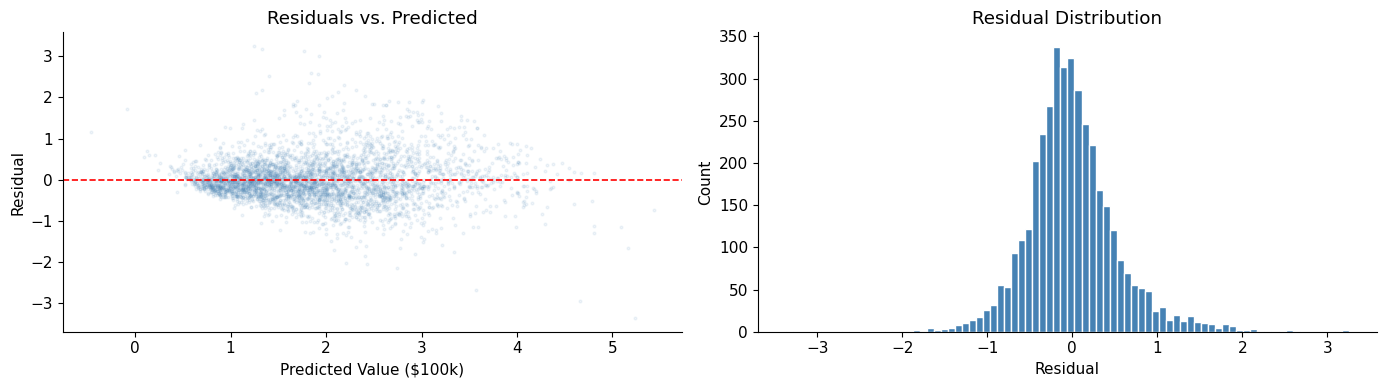

In [16]:
best_model = grid_search.best_estimator_
y_pred     = best_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Test RMSE (Ridge, degree-{POLY_DEGREE}): {test_rmse:.4f}  ($100k)')
print(f'In dollar terms: ± ${test_rmse * 100_000:,.0f}')

# Residual plot
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(y_pred, residuals, alpha=0.08, s=4, color=COLORS[0])
axes[0].axhline(0, color='red', lw=1.2, linestyle='--')
axes[0].set_xlabel('Predicted Value ($100k)')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs. Predicted')

axes[1].hist(residuals, bins=80, color=COLORS[0], edgecolor='white')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('assets/ridge_residuals.png', dpi=120, bbox_inches='tight')
plt.show()


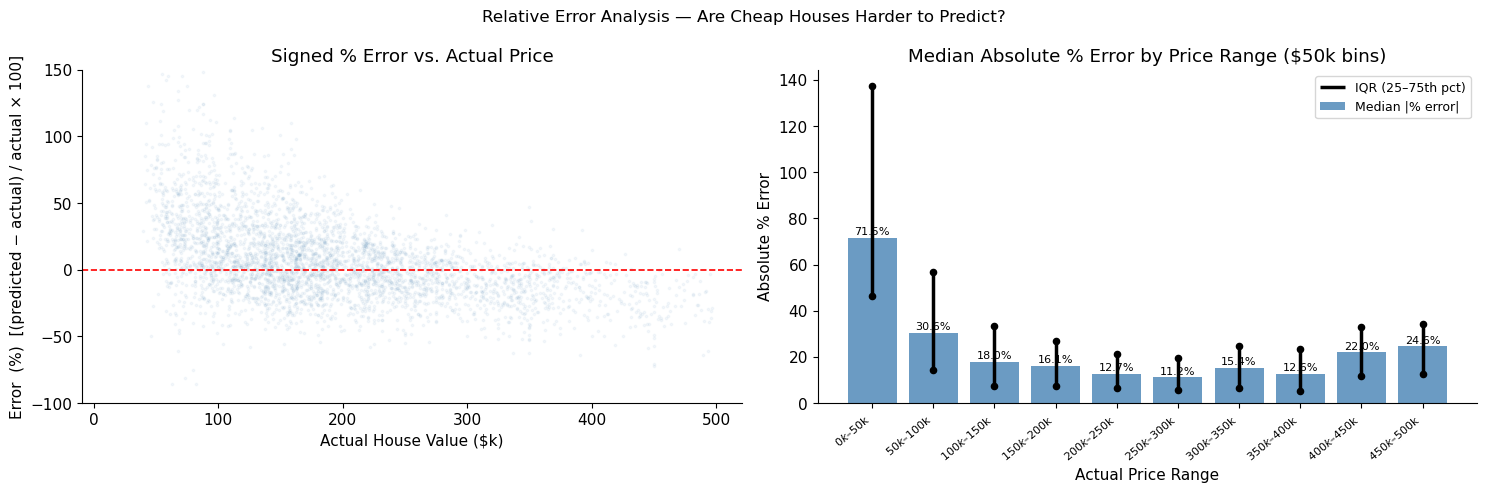

MAPE (mean absolute % error): 24.5%
Median absolute % error     : 17.1%


In [17]:
bin_width_k = 50  # bin width in $k — try 25, 50, 100 to see coarser/finer breakdowns

pct_error = (y_pred - y_test) / y_test * 100          # signed: + = over-predicted
abs_pct_error = np.abs(pct_error)

price_dollars = y_test * 100_000
bin_width = bin_width_k * 1_000
max_price = int(np.ceil(price_dollars.max() / bin_width) * bin_width) + bin_width
bins = np.arange(0, max_price, bin_width)
labels = [f'${int(b/1000)}k–${int((b+bin_width)/1000)}k' for b in bins[:-1]]
price_bin = pd.cut(price_dollars, bins=bins, labels=labels)

bin_stats = pd.DataFrame({
    'abs_pct_error': abs_pct_error,
    'pct_error': pct_error,
    'price_bin': price_bin,
}).groupby('price_bin', observed=True).agg(
    median_abs_pct=('abs_pct_error', 'median'),
    p25=('abs_pct_error', lambda x: np.percentile(x, 25)),
    p75=('abs_pct_error', lambda x: np.percentile(x, 75)),
    n=('abs_pct_error', 'count'),
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: scatter of signed % error vs actual price
axes[0].scatter(price_dollars / 1000, pct_error, alpha=0.05, s=3, color=COLORS[0])
axes[0].axhline(0, color='red', lw=1.2, linestyle='--')
axes[0].set_xlabel('Actual House Value ($k)')
axes[0].set_ylabel('Error  (%)  [(predicted − actual) / actual × 100]')
axes[0].set_title('Signed % Error vs. Actual Price')
axes[0].set_ylim(-100, 150)

# Right: binned median absolute % error with IQR band
x_pos = np.arange(len(bin_stats))
axes[1].bar(x_pos, bin_stats['median_abs_pct'], color=COLORS[0], alpha=0.8, label='Median |% error|')
axes[1].vlines(x_pos,
               bin_stats['p25'], bin_stats['p75'],
               color='black', lw=2.5, label='IQR (25–75th pct)')
axes[1].scatter(x_pos, bin_stats['p75'], color='black', s=20, zorder=5)
axes[1].scatter(x_pos, bin_stats['p25'], color='black', s=20, zorder=5)

for i, (idx, row) in enumerate(bin_stats.iterrows()):
    axes[1].text(i, row['median_abs_pct'] + 0.5, f"{row['median_abs_pct']:.1f}%",
                 ha='center', va='bottom', fontsize=8)

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(bin_stats.index, rotation=40, ha='right', fontsize=8)
axes[1].set_xlabel('Actual Price Range')
axes[1].set_ylabel('Absolute % Error')
axes[1].set_title(f'Median Absolute % Error by Price Range (${bin_width_k}k bins)')
axes[1].legend(fontsize=9)

plt.suptitle('Relative Error Analysis — Are Cheap Houses Harder to Predict?', fontsize=12)
plt.tight_layout()
plt.savefig('assets/relative_error_by_price.png', dpi=130, bbox_inches='tight')
plt.show()

mape = abs_pct_error.mean()
print(f'MAPE (mean absolute % error): {mape:.1f}%')
print(f'Median absolute % error     : {abs_pct_error.median():.1f}%')

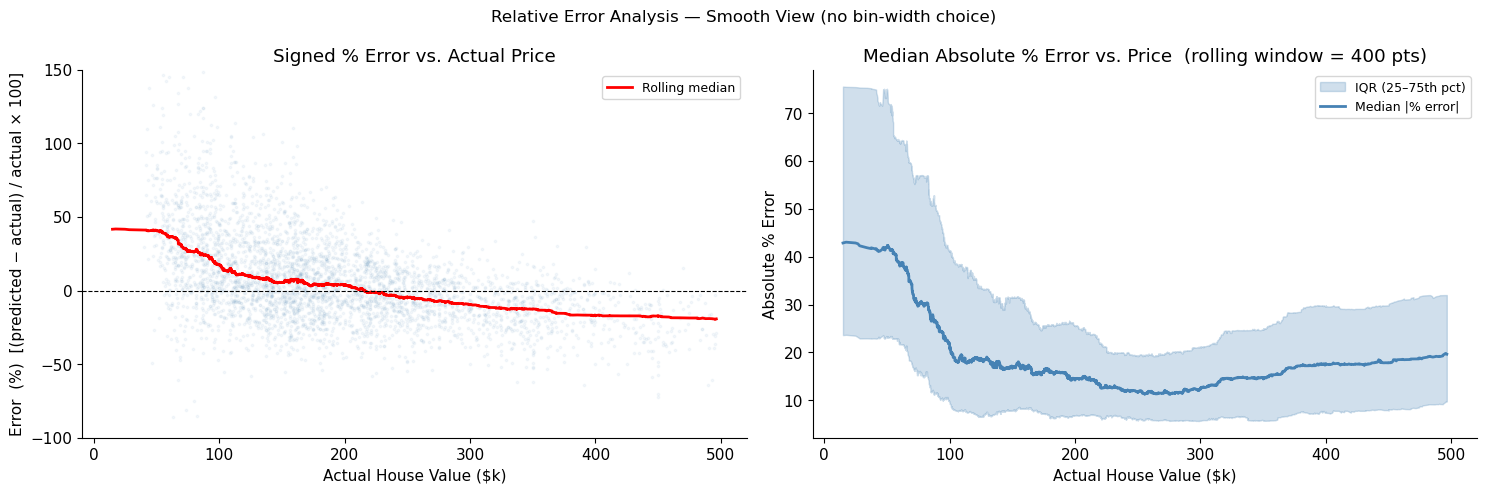

In [18]:
SMOOTH_WINDOW = 400  # number of nearest neighbors (by price) used for rolling quantiles

# Sort test points by actual price so the rolling window is price-ordered
sort_idx = np.argsort(price_dollars.values)
price_s  = price_dollars.values[sort_idx] / 1_000   # in $k
pct_s    = pct_error.values[sort_idx]
abs_s    = abs_pct_error.values[sort_idx]

kw = dict(window=SMOOTH_WINDOW, center=True, min_periods=50)
med_signed = pd.Series(pct_s).rolling(**kw).median()
med_abs    = pd.Series(abs_s).rolling(**kw).median()
p25        = pd.Series(abs_s).rolling(**kw).quantile(0.25)
p75        = pd.Series(abs_s).rolling(**kw).quantile(0.75)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: scatter + rolling median of signed % error
axes[0].scatter(price_s, pct_s, alpha=0.05, s=3, color=COLORS[0])
axes[0].plot(price_s, med_signed, color='red', lw=2, label='Rolling median')
axes[0].axhline(0, color='black', lw=0.8, linestyle='--')
axes[0].set_ylim(-100, 150)
axes[0].set_xlabel('Actual House Value ($k)')
axes[0].set_ylabel('Error  (%)  [(predicted − actual) / actual × 100]')
axes[0].set_title('Signed % Error vs. Actual Price')
axes[0].legend(fontsize=9)

# Right: rolling median absolute % error + IQR band
axes[1].fill_between(price_s, p25, p75, alpha=0.25, color=COLORS[0], label='IQR (25–75th pct)')
axes[1].plot(price_s, med_abs, color=COLORS[0], lw=2, label='Median |% error|')
axes[1].set_xlabel('Actual House Value ($k)')
axes[1].set_ylabel('Absolute % Error')
axes[1].set_title(f'Median Absolute % Error vs. Price  (rolling window = {SMOOTH_WINDOW} pts)')
axes[1].legend(fontsize=9)

plt.suptitle('Relative Error Analysis — Smooth View (no bin-width choice)', fontsize=12)
plt.tight_layout()
plt.savefig('assets/relative_error_smooth.png', dpi=130, bbox_inches='tight')
plt.show()

The smooth curve above shows the same signal as the bar chart, but without a bin-width choice. Both views are complementary: the bars give precise per-range numbers; the smooth curve makes the overall trend and local anomalies (the \$300k bump, the rise above \$400k) easier to read at a glance.

---

**What does this plot tell us?**

The right panel reveals a clear pattern: a **steep monotonic decline** from the cheapest houses down to a sweet spot around \$250k–\$300k, followed by a gradual rise at the expensive end.

**Very cheap houses (\$0–\$50k) — 71.5% median error, IQR reaching ~140%**

This is an extreme segment. Almost no California census blocks reported a median value below \$50k in 1990, so the model has barely any training signal here. The enormous IQR (the whisker reaches ~140%) tells us predictions are nearly random — the few data points are so heterogeneous that even their central tendency is uncertain.

**The monotonic decline (\$50k → \$250k) — 30.5% → 11.8%**

Error falls steadily as house value increases. Two effects drive this:

1. *Data density.* The training distribution is centered around \$150k–\$300k. As we move right across this range, the model sees progressively more examples and fits better.
2. *Percentage amplification.* A fixed absolute dollar error of, say, \$15k is 30% of a \$50k house but only 6% of a \$250k house. Even if prediction quality were identical across the range, the relative error metric would still show this downward slope.

**Sweet spot (\$250k–\$300k) — 11.8% median error**

This is where the model performs best: the highest concentration of training data, the most consistent income-location-price relationships, and the lowest percentage amplification effect. Absolute dollar errors in this bin are likely similar to neighboring bins — the relative metric just favors this range.

**The slight bump at \$300k–\$350k (15.4%) then recovery at \$350k–\$400k (12.5%)**

This small anomaly is worth noting. One plausible explanation is a feature interaction: blocks in the \$300k–\$350k range may straddle a geographic boundary (e.g., the edge of a high-demand coastal county vs. an inland suburb) where the model's polynomial features produce a local misfit. With only 8 census variables, the model cannot distinguish otherwise-similar blocks that sit on opposite sides of a neighborhood boundary.

**Expensive houses (\$400k–\$500k) — rising to 22–24.5%**

Error climbs again at the high end for structural reasons:

1. *Proximity to the censoring boundary.* We removed the hard-capped \$500k rows, but blocks just below that cap may still carry artifacts of the censoring process — their features can be systematically unusual relative to blocks priced well below the ceiling.
2. *Luxury non-linearities.* High-end prices reflect factors the 8 census features cannot capture: school district prestige, architectural quality, micro-neighborhood cachet. The model undershoots these values.
3. *Sparse data.* Like the cheap end, few training examples exist here, so the model cannot specialize.

**Left panel — signed errors**

The scatter confirms the directional story: cheap houses are overwhelmingly **over-predicted** (positive signed error, large upward spread), while expensive houses cluster just below the zero line, reflecting systematic **under-prediction**. This is the classic **regression-to-the-mean** bias — a linear model trained on an asymmetric distribution anchors predictions toward the bulk of the data, dragging cheap predictions up and expensive predictions down.

**Takeaway**: relative (percentage) error is a more honest evaluation metric than RMSE for datasets with wide price ranges. RMSE would mask the poor performance at the extremes because those segments are numerically small and infrequent.

---
<a id='ex11'></a>
### Exercise 1.1 — Effect of Polynomial Degree (Basic)

So far we used `POLY_DEGREE = 2`. In this exercise you will compare degree 1, 2, and 3 to see how polynomial degree interacts with regularization.

**Tasks:**
1. For each degree in `[1, 2, 3]`, build a Ridge pipeline, run `GridSearchCV` with the same `ALPHAS`, and record the best CV RMSE and the corresponding best α.
2. Print a summary table.
3. Answer: does a higher polynomial degree always improve test performance? Why or why not?


In [19]:
rows = []

for degree in [1, 2, 3]:
    pipe = Pipeline([
        ('log_transform', log_preprocessor),
        ('poly',   PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge',  Ridge()),
    ])

    gs = GridSearchCV(
        pipe,
        {'ridge__alpha': ALPHAS},
        cv=CV_FOLDS,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
    )
    gs.fit(X_train, y_train)

    best_alpha    = gs.best_params_['ridge__alpha']
    best_cv_rmse  = np.sqrt(-gs.best_score_)
    test_rmse     = np.sqrt(mean_squared_error(y_test, gs.best_estimator_.predict(X_test)))

    rows.append({'degree': degree, 'best_alpha': round(best_alpha, 4),
                 'cv_rmse': round(best_cv_rmse, 4), 'test_rmse': round(test_rmse, 4)})
    print(f'degree={degree}  best_alpha={best_alpha:.4f}  CV RMSE={best_cv_rmse:.4f}  Test RMSE={test_rmse:.4f}')

print()
print(pd.DataFrame(rows).to_string(index=False))


degree=1  best_alpha=2.5929  CV RMSE=0.6183  Test RMSE=0.6285
degree=2  best_alpha=0.0024  CV RMSE=0.5452  Test RMSE=0.5513
degree=3  best_alpha=0.0574  CV RMSE=0.5336  Test RMSE=0.5391

 degree  best_alpha  cv_rmse  test_rmse
      1      2.5929   0.6183     0.6285
      2      0.0024   0.5452     0.5513
      3      0.0574   0.5336     0.5391


---
<a id='ex12'></a>
### Exercise 1.2 — Ridge vs. Lasso

**Ridge** (L2) shrinks all coefficients toward zero but rarely to exactly zero.  
**Lasso** (L1) tends to produce **sparse** models — many coefficients become exactly zero, effectively performing feature selection.

**Tasks:**
1. Build a Lasso pipeline (same structure: `PolynomialFeatures → StandardScaler → Lasso`) and tune `lasso__alpha` with `GridSearchCV`.
2. Compare test RMSE for Ridge and Lasso.
3. Count how many of the degree-2 polynomial coefficients are exactly zero for each model. What does this tell you about feature selection?
4. Plot the top-20 non-zero Lasso coefficients.


Ridge  best_alpha=0.0024  Test RMSE=0.5513
Lasso  best_alpha=0.0001  Test RMSE=0.5646

Total features (degree-2 poly): 44
Ridge zero coefficients : 0 / 44
Lasso zero coefficients : 6 / 44


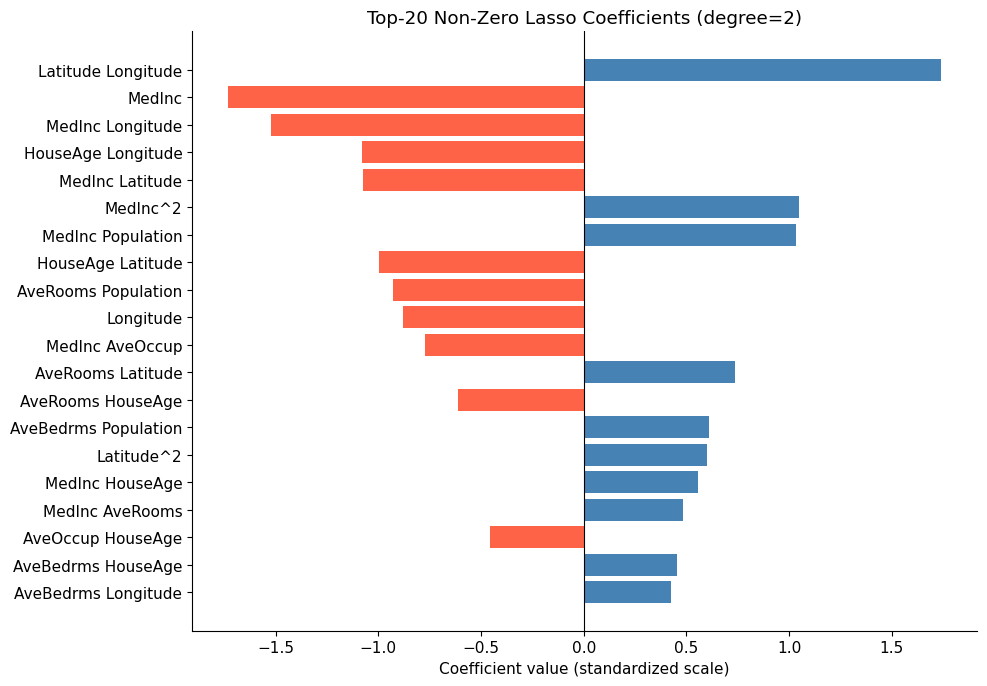

In [20]:
DEGREE = 2

ridge_pipe = Pipeline([
    ('log_transform', log_preprocessor),
    ('poly',   PolynomialFeatures(degree=DEGREE, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge',  Ridge()),
])
ridge_gs = GridSearchCV(ridge_pipe, {'ridge__alpha': ALPHAS}, cv=CV_FOLDS,
                        scoring='neg_mean_squared_error', n_jobs=-1)
ridge_gs.fit(X_train, y_train)

lasso_pipe = Pipeline([
    ('log_transform', log_preprocessor),
    ('poly',   PolynomialFeatures(degree=DEGREE, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lasso',  Lasso(max_iter=10_000)),
])
lasso_gs = GridSearchCV(lasso_pipe, {'lasso__alpha': ALPHAS}, cv=CV_FOLDS,
                        scoring='neg_mean_squared_error', n_jobs=-1)
lasso_gs.fit(X_train, y_train)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_gs.best_estimator_.predict(X_test)))
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_gs.best_estimator_.predict(X_test)))

print(f'Ridge  best_alpha={ridge_gs.best_params_["ridge__alpha"]:.4f}  Test RMSE={ridge_rmse:.4f}')
print(f'Lasso  best_alpha={lasso_gs.best_params_["lasso__alpha"]:.4f}  Test RMSE={lasso_rmse:.4f}')

ridge_coefs = ridge_gs.best_estimator_.named_steps['ridge'].coef_
lasso_coefs = lasso_gs.best_estimator_.named_steps['lasso'].coef_
n_total = len(ridge_coefs)

print(f'\nTotal features (degree-{DEGREE} poly): {n_total}')
print(f'Ridge zero coefficients : {(ridge_coefs == 0).sum()} / {n_total}')
print(f'Lasso zero coefficients : {(lasso_coefs == 0).sum()} / {n_total}')

log_names  = ridge_gs.best_estimator_.named_steps['log_transform'].get_feature_names_out()
poly_names = lasso_gs.best_estimator_.named_steps['poly'].get_feature_names_out(log_names)

nonzero_mask  = lasso_coefs != 0
nonzero_names = poly_names[nonzero_mask]
nonzero_vals  = lasso_coefs[nonzero_mask]

top20_idx   = np.argsort(np.abs(nonzero_vals))[-20:]
top20_names = nonzero_names[top20_idx]
top20_vals  = nonzero_vals[top20_idx]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20_names, top20_vals,
        color=[COLORS[1] if v < 0 else COLORS[0] for v in top20_vals])
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Coefficient value (standardized scale)')
ax.set_title(f'Top-20 Non-Zero Lasso Coefficients (degree={DEGREE})')
plt.tight_layout()
plt.savefig('assets/lasso_top20_coefs.png', dpi=120, bbox_inches='tight')
plt.show()


---
<a id='part2'></a>
## 4. Part 2 — Online Learning with SGDRegressor

<a id='scale'></a>
### 4.1 When Data Doesn't Fit in Memory

The California Housing dataset fits comfortably in RAM. But in the real world, datasets are often large enough to exceed available memory:

- **Streaming music platforms** accumulate audio features for millions of new songs every year.
- **E-commerce sites** log billions of user interactions monthly.
- **Medical imaging pipelines** generate terabytes of feature matrices.

For these scenarios, loading all data before training is impossible. The solution is **online (incremental) learning**: process one mini-batch at a time, update model weights, discard the batch, and move on — without ever holding the full dataset in RAM.


In [21]:
# Memory footprint estimate for the MSD dataset
n_train   = MSD_TRAIN_ROWS
n_test    = MSD_TEST_ROWS
n_feat    = 90
bytes_f64 = 8

raw_mb = (n_train + n_test) * (n_feat + 1) * bytes_f64 / 1024**2
print(f'Raw feature matrix ({n_train + n_test:,} rows × {n_feat} features): ~{raw_mb:.0f} MB')

# Degree-2 polynomial features would be huge
n_poly2 = PolynomialFeatures(degree=2, include_bias=False).fit(np.zeros((1, n_feat))).n_output_features_
poly2_gb = (n_train + n_test) * n_poly2 * bytes_f64 / 1024**3
print(f'After degree-2 expansion ({n_poly2:,} features): ~{poly2_gb:.0f} GB  ← impossible to load at once')

Raw feature matrix (515,345 rows × 90 features): ~358 MB
After degree-2 expansion (4,185 features): ~16 GB  ← impossible to load at once


Even the raw matrix for a full year (1 M songs) would be ~750 MB. With feature engineering and multiple frames it quickly exceeds available RAM. Solution: stream data in chunks and use `partial_fit` for online learning.

<a id='data2'></a>
### 4.2 Dataset: Year Prediction MSD

The **Million Song Dataset (MSD)** is a collection of audio features and metadata for one million contemporary pop music tracks. This lab uses a preprocessed subset from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/203/yearpredictionmsd).

| Property | Value |
|----------|-------|
| Training samples | 515,345 |
| Test samples | 51,630 |
| Features | 90 (timbre-based audio) |
| Target | Song release year (1922 – 2011) |
| File size | ~700 MB unzipped |

**Feature description:**  
Features 1–12 are the **timbre average**: the mean of each of 12 [timbre](https://en.wikipedia.org/wiki/Timbre) components extracted by the Echo Nest API. Timbre captures the texture and tone quality of a sound — roughly what makes a piano sound different from a violin even at the same pitch and loudness.  
Features 13–90 are the **timbre covariance**: the 78 upper-triangle values of the 12×12 covariance matrix, capturing how the timbre components vary together across the song.

**Task:** Predict the year a song was released from these audio statistics.

> **Important**: The train/test split is **pre-defined** by the dataset creators (first 515,345 rows = train, last 51,630 = test). Do not shuffle the file; use this fixed split to ensure comparable results.


In [22]:
def _reporthook(count, block_size, total_size):
    pct = min(100, count * block_size * 100 // total_size) if total_size > 0 else 0
    mb  = count * block_size / 1024**2
    print(f'\r  {pct:3d}%  ({mb:.0f} MB downloaded)', end='', flush=True)

if not os.path.exists(MSD_DATA_FILE):
    zip_file = 'YearPredictionMSD.txt.zip'
    if not os.path.exists(zip_file):
        print(f'Downloading {MSD_URL} ...')
        print('(~200 MB compressed; may take a few minutes on Colab)')
        urllib.request.urlretrieve(MSD_URL, zip_file, reporthook=_reporthook)
        print()
    print('Extracting ...')
    with zipfile.ZipFile(zip_file, 'r') as z:
        z.extractall('.')
    size_mb = os.path.getsize(MSD_DATA_FILE) / 1024**2
    print(f'Done.  {MSD_DATA_FILE}  ({size_mb:.0f} MB)')
else:
    size_mb = os.path.getsize(MSD_DATA_FILE) / 1024**2
    print(f'Dataset already present: {MSD_DATA_FILE}  ({size_mb:.0f} MB)')


Dataset already present: YearPredictionMSD.txt  (428 MB)


Sample shape: (10000, 91)
Year range : 1930 – 2010
Year mean  : 1998.9
Year std   : 10.2


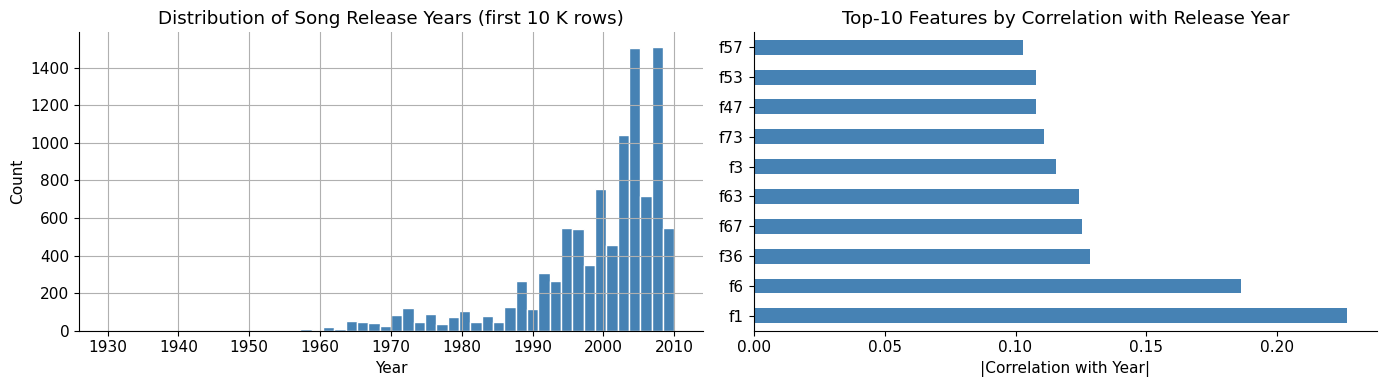

In [23]:
# Quick EDA — read a small slice so we don't load the full file
df_eda = pd.read_csv(MSD_DATA_FILE, header=None, nrows=10_000)
feature_cols = ['year'] + [f'f{i}' for i in range(1, 91)]
df_eda.columns = feature_cols

print(f'Sample shape: {df_eda.shape}')
print(f'Year range : {df_eda["year"].min()} – {df_eda["year"].max()}')
print(f'Year mean  : {df_eda["year"].mean():.1f}')
print(f'Year std   : {df_eda["year"].std():.1f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_eda['year'].hist(bins=50, ax=axes[0], color=COLORS[0], edgecolor='white')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Song Release Years (first 10 K rows)')

corrs = df_eda.corr()['year'].drop('year').abs().sort_values(ascending=False).head(10)
corrs.plot(kind='barh', ax=axes[1], color=COLORS[0])
axes[1].set_xlabel('|Correlation with Year|')
axes[1].set_title('Top-10 Features by Correlation with Release Year')

plt.tight_layout()
plt.savefig('assets/msd_eda.png', dpi=120, bbox_inches='tight')
plt.show()


<a id='sgd'></a>
### 4.3 SGDRegressor and `partial_fit`

#### From Batch GD to Mini-Batch SGD

**Batch gradient descent** computes the gradient over *all* N training samples before each weight update:

$$\mathbf{w} \leftarrow \mathbf{w} - \eta \cdot \frac{1}{N} \sum_{i=1}^{N} \nabla_{\mathbf{w}} \mathcal{L}(x_i, y_i)$$

This is exact but requires all data in memory and is slow for large N.

**Stochastic gradient descent (SGD)** uses a single random sample per update:  
$$\mathbf{w} \leftarrow \mathbf{w} - \eta \cdot \nabla_{\mathbf{w}} \mathcal{L}(x_i, y_i)$$

**Mini-batch SGD** strikes a balance — use a small batch of B samples:
$$\mathbf{w} \leftarrow \mathbf{w} - \eta \cdot \frac{1}{B} \sum_{i \in \text{batch}} \nabla_{\mathbf{w}} \mathcal{L}(x_i, y_i)$$

This is both memory-efficient and statistically stable.

#### `partial_fit` in sklearn

`SGDRegressor.partial_fit(X_batch, y_batch)` applies **one pass** of mini-batch SGD on the provided batch without forgetting previously learned weights. Calling it repeatedly on successive batches (or even on multiple epochs over the same data) implements full online/incremental learning.

```python
sgd = SGDRegressor(learning_rate='constant', eta0=0.01)

for chunk in pd.read_csv('bigfile.csv', chunksize=50_000):
    X_chunk = chunk.iloc[:, 1:].values
    y_chunk = chunk.iloc[:, 0].values
    sgd.partial_fit(X_scaled, y_chunk)   # weights updated in-place
```

**Key rule**: the scaler must be fitted on **training data only** — never re-fitted on test data or future production chunks — then applied (`transform`) consistently everywhere. The cleanest approach (used in Exercise 2.1) is a dedicated first pass over **all** training chunks with `StandardScaler.partial_fit`, which gives accurate statistics regardless of dataset size. For datasets where two passes are prohibitively expensive, fitting on a **representative sample** (e.g. the first few chunks) is a common practical shortcut, provided the sample reflects the overall distribution.


---
<a id='ex21'></a>
### Exercise 2.1 — Implement the Mini-Batch Training Loop (Basic)

Implement one epoch of mini-batch SGD over the MSD training data using `SGDRegressor.partial_fit`.

**Tasks:**
1. Create an `SGDRegressor` with `loss='squared_error'`, `learning_rate='constant'`, `eta0=0.001`, `random_state=42`.
2. Create a `StandardScaler`.
3. **Pass 1 — fit the scaler**: stream through the training rows and call `msd_scaler.partial_fit(X_chunk)` on every chunk so the scaler captures the full training distribution.
4. **Pass 2 — train**: stream through the data again. For each chunk:
   - Extract `y_chunk` (column 0) and `X_chunk` (columns 1–90).
   - Transform `X_chunk` with the already-fitted scaler.
   - Call `sgd.partial_fit(X_scaled, y_chunk)`.
   - Compute RMSE on the current chunk (after the update) and store it in `chunk_rmses`.
5. Print the total number of chunks processed and the final chunk RMSE.

> **Practical note on scaler fitting**: Pass 1 here scans *all* training chunks with `partial_fit`, giving the most accurate mean and variance estimates — ideal when two passes are affordable. For very large datasets where two passes are too costly, fitting on a **representative sample** (e.g. the first chunk or a random subset) is an acceptable approximation, provided the sample is reasonably representative of the full distribution. In production streaming systems where the data distribution can shift over time (**concept drift**), consider periodically re-calling `partial_fit` on a recent window of data to keep the scaler's statistics fresh.

**Expected output**: ~10–11 chunks processed, final chunk RMSE around 8–11 years.


In [24]:
msd_scaler = StandardScaler()
sgd = SGDRegressor(loss='squared_error', learning_rate='constant', eta0=0.001, random_state=42)

for chunk in pd.read_csv(MSD_DATA_FILE, header=None, nrows=MSD_TRAIN_ROWS, chunksize=CHUNK_SIZE):
    msd_scaler.partial_fit(chunk.iloc[:, 1:].values)

chunk_rmses = []
for chunk in pd.read_csv(MSD_DATA_FILE, header=None, nrows=MSD_TRAIN_ROWS, chunksize=CHUNK_SIZE):
    y_chunk = chunk.iloc[:, 0].values
    X_chunk = msd_scaler.transform(chunk.iloc[:, 1:].values)
    sgd.partial_fit(X_chunk, y_chunk)
    chunk_rmses.append(np.sqrt(mean_squared_error(y_chunk, sgd.predict(X_chunk))))

print(f'Chunks processed : {len(chunk_rmses)}')
print(f'Final chunk RMSE : {chunk_rmses[-1]:.4f} years')


Chunks processed : 93
Final chunk RMSE : 9.7518 years


---
<a id='ex22'></a>
### Exercise 2.2 — Plot the Convergence Curve (Basic)

Using the `chunk_rmses` list from Exercise 2.1, plot the RMSE as a function of chunk number to visualise convergence within one epoch.

**Tasks:**
1. Plot RMSE vs. chunk index.
2. Add axis labels and a title.
3. Answer: does the model converge within a single pass? What pattern do you observe?


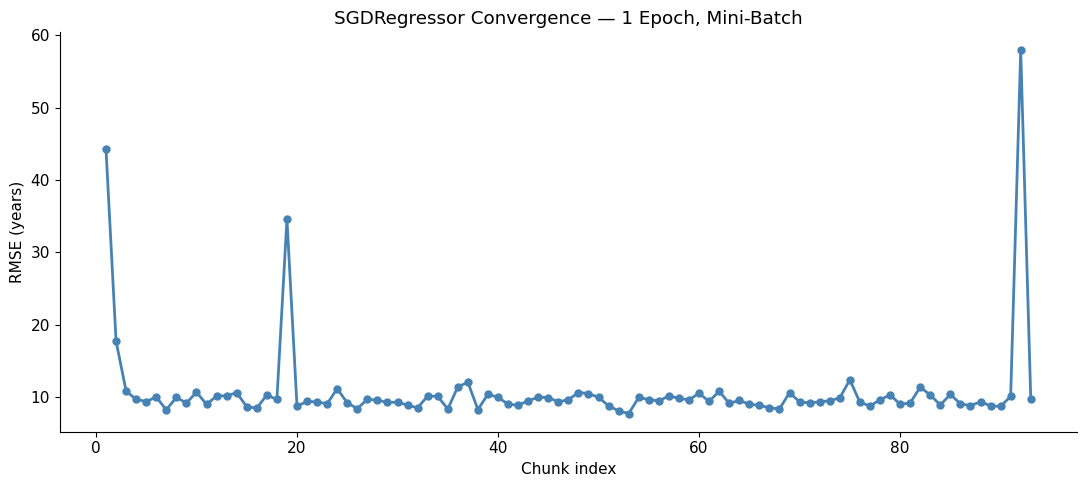

In [25]:
fig, ax = plt.subplots()
ax.plot(range(1, len(chunk_rmses) + 1), chunk_rmses, color=COLORS[0], lw=2, marker='o', ms=5)
ax.set_xlabel('Chunk index')
ax.set_ylabel('RMSE (years)')
ax.set_title('SGDRegressor Convergence — 1 Epoch, Mini-Batch')
plt.tight_layout()
plt.savefig('assets/sgd_convergence.png', dpi=120, bbox_inches='tight')
plt.show()


---
<a id='ex23'></a>
### Exercise 2.3 — Multi-Epoch Training (Intermediate)

One pass through the data is often insufficient. Run `N_EPOCHS` epochs and track **validation RMSE** on the held-out test set after each epoch.

**Tasks:**
1. Load the test set: `pd.read_csv(MSD_DATA_FILE, header=None, skiprows=MSD_TRAIN_ROWS)`. Scale X_test using the **already-fitted** scaler from Exercise 2.1 (`msd_scaler`).
2. Train a fresh `SGDRegressor` (same settings as 2.1) for `N_EPOCHS` epochs, recording both per-chunk train RMSE and per-epoch validation RMSE. **Shuffle the training data at the start of each epoch** so the model sees a different ordering every pass.
3. Plot train RMSE per chunk (all epochs concatenated) and validation RMSE per epoch on the same figure.
4. Answer: does validation RMSE improve across epochs? When does it saturate?


Epoch  1/10  val RMSE=9.9274 years
Epoch  2/10  val RMSE=10.0818 years
Epoch  3/10  val RMSE=10.0053 years
Epoch  4/10  val RMSE=9.8727 years
Epoch  5/10  val RMSE=9.8559 years
Epoch  6/10  val RMSE=9.9298 years
Epoch  7/10  val RMSE=10.3874 years
Epoch  8/10  val RMSE=9.7426 years
Epoch  9/10  val RMSE=9.7712 years
Epoch 10/10  val RMSE=9.8436 years


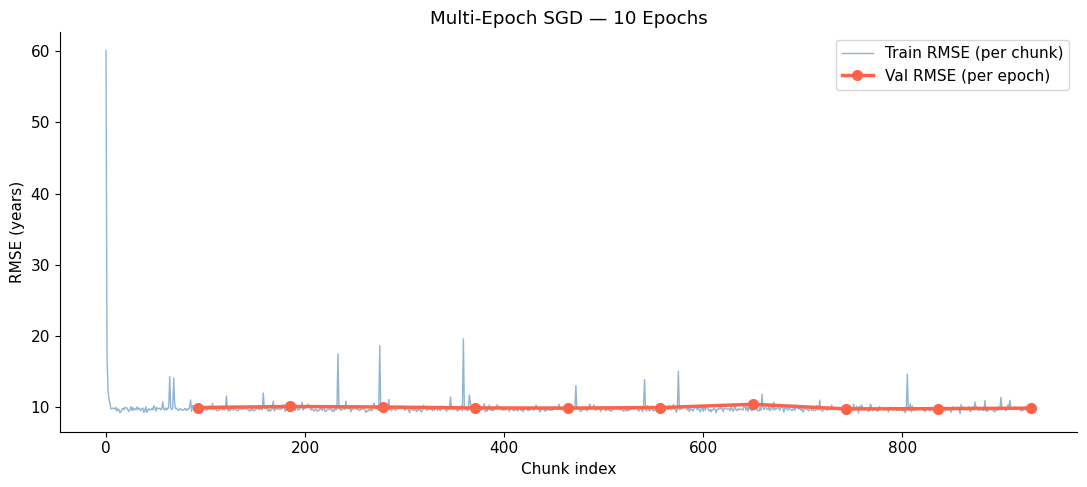

In [26]:
df_train_full = pd.read_csv(MSD_DATA_FILE, header=None, nrows=MSD_TRAIN_ROWS)
X_train_msd   = msd_scaler.transform(df_train_full.iloc[:, 1:].values)
y_train_msd   = df_train_full.iloc[:, 0].values
del df_train_full

df_test_msd  = pd.read_csv(MSD_DATA_FILE, header=None, skiprows=MSD_TRAIN_ROWS)
X_test_msd   = msd_scaler.transform(df_test_msd.iloc[:, 1:].values)
y_test_msd   = df_test_msd.iloc[:, 0].values
del df_test_msd

sgd_multi = SGDRegressor(loss='squared_error', learning_rate='constant', eta0=0.001, random_state=RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)

all_train_rmses = []
epoch_val_rmses = []

for epoch in range(N_EPOCHS):
    idx = rng.permutation(len(y_train_msd))
    for start in range(0, len(y_train_msd), CHUNK_SIZE):
        batch = idx[start:start + CHUNK_SIZE]
        sgd_multi.partial_fit(X_train_msd[batch], y_train_msd[batch])
        all_train_rmses.append(
            np.sqrt(mean_squared_error(y_train_msd[batch], sgd_multi.predict(X_train_msd[batch])))
        )
    val_rmse = np.sqrt(mean_squared_error(y_test_msd, sgd_multi.predict(X_test_msd)))
    epoch_val_rmses.append(val_rmse)
    print(f'Epoch {epoch + 1:2d}/{N_EPOCHS}  val RMSE={val_rmse:.4f} years')

chunks_per_epoch = len(all_train_rmses) // N_EPOCHS
epoch_x = [(e + 1) * chunks_per_epoch - 1 for e in range(N_EPOCHS)]

fig, ax = plt.subplots()
ax.plot(all_train_rmses, color=COLORS[0], lw=1, alpha=0.6, label='Train RMSE (per chunk)')
ax.plot(epoch_x, epoch_val_rmses, color=COLORS[1], lw=2.5, marker='o', ms=7, label='Val RMSE (per epoch)')
ax.set_xlabel('Chunk index')
ax.set_ylabel('RMSE (years)')
ax.set_title(f'Multi-Epoch SGD — {N_EPOCHS} Epochs')
ax.legend()
plt.tight_layout()
plt.savefig('assets/sgd_multi_epoch.png', dpi=120, bbox_inches='tight')
plt.show()


---
<a id='ex24'></a>
### Exercise 2.4 — Learning Rate Exploration (Key Exercise)

The learning rate `eta0` is the most sensitive hyperparameter in SGD. Too large, and gradient updates overshoot the minimum, causing **divergence**. Too small, and learning is too slow to be practical.

**Tasks:**
1. Train five separate `SGDRegressor` models, each with a different `eta0` from `[0.0001, 0.001, 0.01, 0.1, 1.0]`, each for **one epoch** over the training data.
2. For each model, track per-chunk RMSE. If RMSE becomes `NaN` or `inf`, stop training that model early and mark it as diverged.
3. Plot all five convergence curves on the same axes. Cap the y-axis at 150 years so diverging runs don't dominate.
4. Answer the following:
   - Which learning rates diverge?
   - Why does a large learning rate cause divergence? Sketch the geometry.
   - What is the cost of using too small a learning rate?


In [27]:
lr_results = {}

for eta in [0.0001, 0.001, 0.01, 0.1, 1.0]:
    model = SGDRegressor(loss='squared_error', learning_rate='constant',
                         eta0=eta, random_state=RANDOM_STATE)
    rmses = []
    diverged = False
    rng_lr = np.random.default_rng(RANDOM_STATE)
    idx = rng_lr.permutation(len(y_train_msd))

    for start in range(0, len(y_train_msd), CHUNK_SIZE):
        batch = idx[start:start + CHUNK_SIZE]
        model.partial_fit(X_train_msd[batch], y_train_msd[batch])
        rmse = np.sqrt(mean_squared_error(y_train_msd[batch], model.predict(X_train_msd[batch])))
        if not np.isfinite(rmse):
            diverged = True
            break
        rmses.append(rmse)

    lr_results[eta] = {'rmses': rmses, 'diverged': diverged}
    status = 'DIVERGED' if diverged else f'final RMSE={rmses[-1]:.4f}'
    print(f'eta0={eta:6.4f}  chunks={len(rmses):3d}  {status}')


eta0=0.0001  chunks= 93  final RMSE=9.5203
eta0=0.0010  chunks= 93  final RMSE=9.8787
eta0=0.0100  chunks= 93  final RMSE=222403478151.5664
eta0=0.1000  chunks= 93  final RMSE=5661567247951.5947
eta0=1.0000  chunks= 93  final RMSE=71337716542036.3438


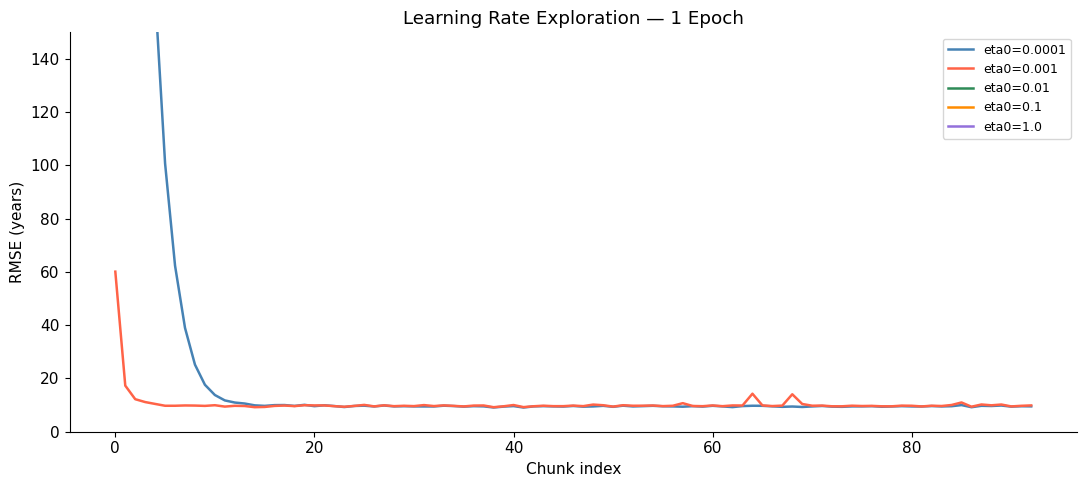

In [28]:
fig, ax = plt.subplots()
for i, (eta, result) in enumerate(lr_results.items()):
    label = f'eta0={eta}' + (' (diverged)' if result['diverged'] else '')
    ax.plot(result['rmses'], color=COLORS[i % len(COLORS)], lw=1.8, label=label)

ax.set_ylim(0, 150)
ax.set_xlabel('Chunk index')
ax.set_ylabel('RMSE (years)')
ax.set_title('Learning Rate Exploration — 1 Epoch')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('assets/sgd_lr_exploration.png', dpi=120, bbox_inches='tight')
plt.show()


---
<a id='ex25'></a>
### Exercise 2.5 — Learning Rate Schedules (Advanced)

A fixed learning rate is a compromise: large enough to converge quickly, small enough to avoid divergence. **Learning rate schedules** decay the rate over time, allowing fast initial progress and fine-grained convergence later.

sklearn's `SGDRegressor` supports several built-in schedules via `learning_rate`:

| Schedule | Formula | Notes |
|----------|---------|-------|
| `'constant'` | `η = eta0` | Fixed; need to tune eta0 |
| `'optimal'` | `η_t = 1 / (α (t + t₀))` | Auto-calculated; ignores eta0 |
| `'invscaling'` | `η_t = eta0 / t^power_t` | Polynomial decay; flexible |

**Tasks:**
1. Train three models for 3 epochs each: `learning_rate='constant'` (eta0=0.001), `learning_rate='optimal'`, and `learning_rate='invscaling'` (eta0=0.001, power_t=0.25).
2. After each epoch, record the validation RMSE on the test set.
3. Plot validation RMSE vs. epoch for all three schedules.
4. Answer: which schedule reaches the lowest validation RMSE? What is the trade-off between `constant` and decaying schedules in the context of streaming data (where the data distribution may shift over time)?


In [29]:
schedules = [
    ('constant',   dict(learning_rate='constant',   eta0=0.001)),
    ('optimal',    dict(learning_rate='optimal')),
    ('invscaling', dict(learning_rate='invscaling',  eta0=0.001, power_t=0.25)),
]

schedule_results = {}

for name, kwargs in schedules:
    model = SGDRegressor(loss='squared_error', random_state=RANDOM_STATE, **kwargs)
    val_rmses = []
    rng_s = np.random.default_rng(RANDOM_STATE)

    for epoch in range(3):
        idx = rng_s.permutation(len(y_train_msd))
        for start in range(0, len(y_train_msd), CHUNK_SIZE):
            batch = idx[start:start + CHUNK_SIZE]
            model.partial_fit(X_train_msd[batch], y_train_msd[batch])
        val_rmse = np.sqrt(mean_squared_error(y_test_msd, model.predict(X_test_msd)))
        val_rmses.append(val_rmse)
        print(f'{name:12s}  epoch {epoch + 1}/3  val RMSE={val_rmse:.4f} years')

    schedule_results[name] = val_rmses

print()


constant      epoch 1/3  val RMSE=9.9274 years
constant      epoch 2/3  val RMSE=10.0818 years
constant      epoch 3/3  val RMSE=10.0053 years
optimal       epoch 1/3  val RMSE=1031632047538.1833 years
optimal       epoch 2/3  val RMSE=573848206953.2244 years
optimal       epoch 3/3  val RMSE=21958444618.4444 years
invscaling    epoch 1/3  val RMSE=9.5400 years
invscaling    epoch 2/3  val RMSE=9.5282 years
invscaling    epoch 3/3  val RMSE=9.5141 years



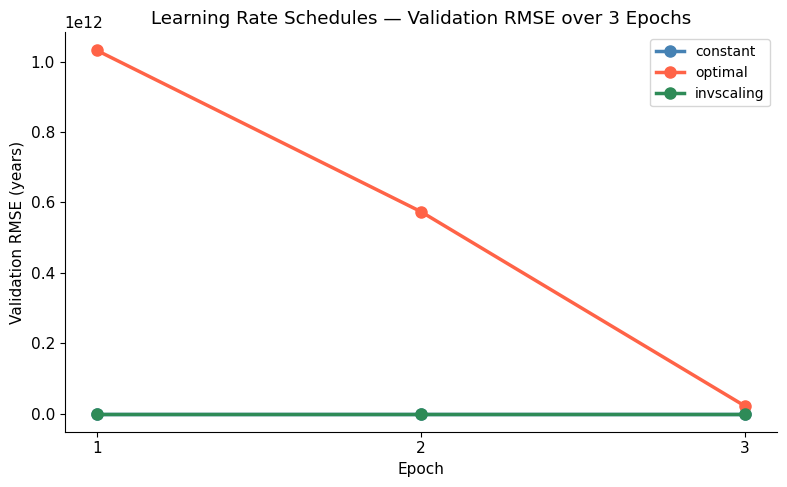

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
for i, (name, val_rmses) in enumerate(schedule_results.items()):
    ax.plot([1, 2, 3], val_rmses, color=COLORS[i], lw=2.5, marker='o', ms=8, label=name)

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation RMSE (years)')
ax.set_xticks([1, 2, 3])
ax.set_title('Learning Rate Schedules — Validation RMSE over 3 Epochs')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('assets/sgd_lr_schedules.png', dpi=120, bbox_inches='tight')
plt.show()


---
<a id='realworld'></a>
## 5. Real-World Considerations

### When to Use Batch vs. Online Learning

| Scenario | Recommendation |
|----------|----------------|
| Data fits in memory, static | Batch (Ridge/Lasso + Pipeline + GridSearchCV) |
| Data too large for RAM | Online (`SGDRegressor.partial_fit` on chunks) |
| Continuous data stream (concept drift) | Online with constant or slowly decaying LR |
| Periodic retraining on large archive | Mini-batch SGD or distributed frameworks (Spark MLlib, Dask-ML) |

### Practical Tips for SGD in Production

**Always scale features.** SGD is sensitive to feature scale; unscaled inputs can cause gradients to differ by orders of magnitude across features, making tuning nearly impossible. Fit the scaler once on a representative sample (or the first chunk) and apply it consistently.

**Monitor for divergence early.** Add a check after the first few chunks: if RMSE is not decreasing or is NaN, stop and reduce `eta0` by a factor of 10.

**Regularization matters even more for SGD.** With noisy mini-batch gradients, models can overfit if run for many epochs without regularization. Use `penalty='l2'` (default) with a non-zero `alpha` in `SGDRegressor`.

**Warm-starting scaler for streaming data.** If your data distribution shifts over time, consider re-fitting the scaler periodically (e.g., every N chunks) or using `StandardScaler` with `partial_fit` to update statistics incrementally.

**Evaluation on held-out data.** The per-chunk train RMSE is noisy (gradient descent is still mid-step). Always evaluate on a separately held-out test set for a reliable performance estimate.

### Pipelines Are Not Directly Compatible with `partial_fit`

sklearn's `Pipeline` object does not support `partial_fit` in all configurations — specifically, you cannot call `pipeline.partial_fit()` if the pipeline contains transformers that need to be fitted incrementally. The typical workaround (as implemented above) is to manage the scaler manually outside the loop and feed pre-scaled chunks to the SGD estimator.


---
<a id='summary'></a>
## 6. Summary and Key Takeaways

### Part 1 — Pipelines and Regularization

- **Pipelines** chain preprocessing and modeling steps into a single object that integrates cleanly with `cross_val_score` and `GridSearchCV`, preventing data leakage.
- **Polynomial features** extend a linear model's capacity to capture non-linear relationships. The expansion is controlled by `degree`; higher degrees increase variance and require stronger regularization.
- **Ridge regression** adds an L2 penalty to the OLS loss: `min ‖Xw − y‖² + α‖w‖²`. It is always uniquely solvable and numerically stable, even with many correlated features.
- **GridSearchCV** evaluates each candidate α using k-fold CV and returns the optimal value. The validation curve shows the classic U-shape: decreasing CV error as α grows (fighting overfitting), then increasing error as α becomes too large (causing underfitting).
- **Lasso** (L1) promotes sparsity — many coefficients become exactly zero — making it useful for feature selection when interpretability matters.

### Part 2 — Online Learning with SGD

- **Mini-batch SGD** updates model weights on small chunks of data without ever loading the full dataset. It is the standard approach for datasets that exceed available RAM or for continuously arriving data.
- **`SGDRegressor.partial_fit`** incrementally updates weights without resetting them. Call it repeatedly on successive chunks or multiple epochs to approximate full-batch training.
- **The learning rate is critical.** Too large → gradient updates overshoot the loss minimum → divergence. Too small → convergence is impractically slow. The `'optimal'` schedule or a constant rate around `eta0 = 0.01` is a good starting point for standardized features.
- **Decaying schedules** (`invscaling`) are good for static datasets but can become too conservative for streaming data with concept drift; prefer `constant` or `optimal` in those settings.

